In [51]:
#1 importer les librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import tkinter as tk

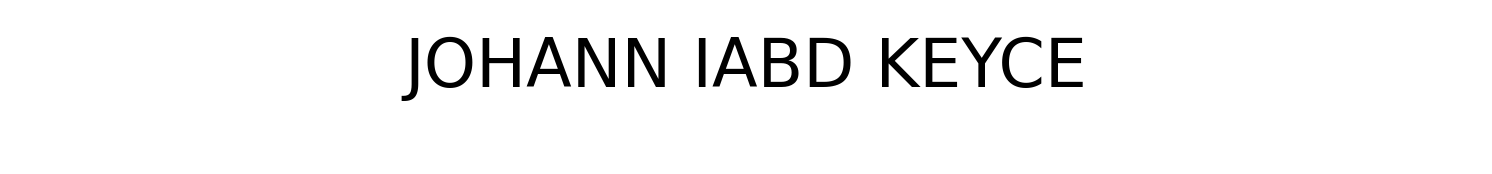

In [52]:
#CE CODE ME SERVIRA A AFFICHER LES GRANDS TITRE
commentaire = "JOHANN IABD KEYCE"
plt.figure(figsize=(19,2))
plt.text(0.5, 0.5, commentaire, fontsize=48, ha="center")
plt.axis("off")
plt.show()

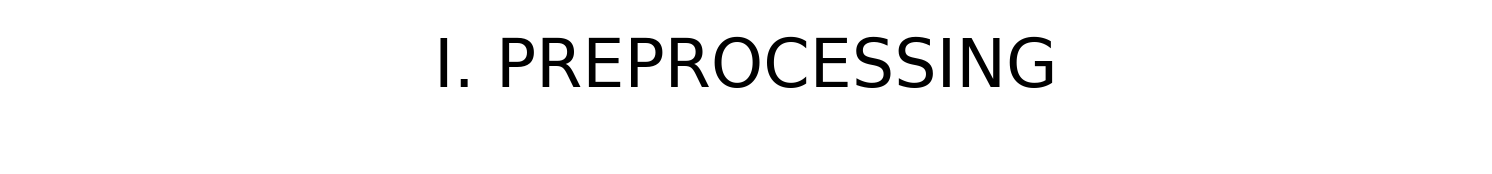

In [53]:
#CE CODE ME SERT A AFFICHER LES GRANDS TITRE
commentaire = "I. PREPROCESSING"
plt.figure(figsize=(19,2))
plt.text(0.5, 0.5, commentaire, fontsize=48, ha="center")
plt.axis("off")
plt.show()


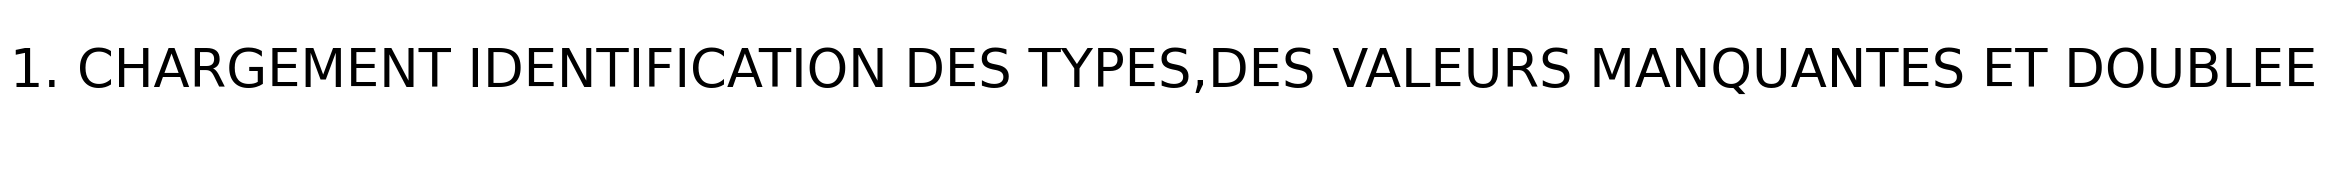

In [54]:
#CE CODE ME SERVIRA A AFFICHER LES GRANDS TITRE
commentaire = "1. CHARGEMENT IDENTIFICATION DES TYPES,DES VALEURS MANQUANTES ET DOUBLEE"
plt.figure(figsize=(19,2))
plt.text(0.5, 0.5, commentaire, fontsize="38", ha="center")
plt.axis("off")
plt.show()

In [55]:
#afficher les premiere colonne
data=pd.read_csv('AER_credit_card_data.csv')
data.head()

,card,reports,age,income,share,expenditure,owner,selfemp,dependents,months,majorcards,active
0,yes,0,37.66667,4.5200,0.033270,124.983300,yes,no,3,54,1,12
1,yes,0,33.25000,2.4200,0.005217,9.854167,no,no,3,34,1,13
2,yes,0,33.66667,4.5000,0.004156,15.000000,yes,no,4,58,1,5
3,yes,0,30.50000,2.5400,0.065214,137.869200,no,no,0,25,1,7
4,yes,0,32.16667,9.7867,0.067051,546.503300,yes,no,2,64,1,5


In [56]:
#recherche des informations de données
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   card         1319 non-null   object 
 1   reports      1319 non-null   int64  
 2   age          1319 non-null   float64
 3   income       1319 non-null   float64
 4   share        1319 non-null   float64
 5   expenditure  1319 non-null   float64
 6   owner        1319 non-null   object 
 7   selfemp      1319 non-null   object 
 8   dependents   1319 non-null   int64  
 9   months       1319 non-null   int64  
 10  majorcards   1319 non-null   int64  
 11  active       1319 non-null   int64  
dtypes: float64(4), int64(5), object(3)
memory usage: 123.8+ KB


In [57]:
#Données statistiques
data.describe()

,reports,age,income,share,expenditure,dependents,months,majorcards,active
count,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000
mean,0.456406,33.213103,3.365376,0.068732,185.057071,0.993935,55.267627,0.817286,6.996967
std,1.345267,10.142783,1.693902,0.094656,272.218917,1.247745,66.271746,0.386579,6.305812
min,0.000000,0.166667,0.210000,0.000109,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,25.416670,2.243750,0.002316,4.583333,0.000000,12.000000,1.000000,2.000000
50%,0.000000,31.250000,2.900000,0.038827,101.298300,1.000000,30.000000,1.000000,6.000000
75%,0.000000,39.416670,4.000000,0.093617,249.035800,2.000000,72.000000,1.000000,11.000000
max,14.000000,83.500000,13.500000,0.906320,3099.505000,6.000000,540.000000,1.000000,46.000000


In [58]:
# Recherche de données manquantes
data.isna().sum()   

card           0
reports        0
age            0
income         0
share          0
expenditure    0
owner          0
selfemp        0
dependents     0
months         0
majorcards     0
active         0
dtype: int64

In [59]:
# Recherche de données dupliquées
duplicates = data[data.duplicated(keep=False)]
print(duplicates)

Empty DataFrame
Columns: [card, reports, age, income, share, expenditure, owner, selfemp, dependents, months, majorcards, active]
Index: []


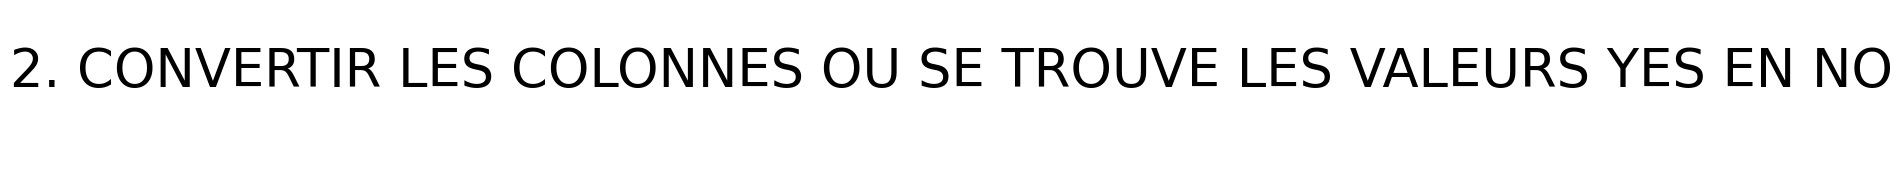

In [60]:
#CE CODE ME SERVIRA A AFFICHER LES GRANDS TITRE
commentaire = "2. CONVERTIR LES COLONNES OU SE TROUVE LES VALEURS YES EN NO"
plt.figure(figsize=(19,2))
plt.text(0.5, 0.5, commentaire, fontsize="38", ha="center")
plt.axis("off")
plt.show()


In [61]:
# Liste des colonnes binaires à encoder
binary_cols = ['card', 'owner', 'selfemp']

In [62]:
# Encodage : yes -> 1, no -> 0
data[binary_cols] = data[binary_cols].applymap(lambda x: 1 if x == 'yes' else 0)

C:\Users\JOHANN\AppData\Local\Temp\ipykernel_17460\2572221243.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  data[binary_cols] = data[binary_cols].applymap(lambda x: 1 if x == 'yes' else 0)


In [63]:
data.head()

,card,reports,age,income,share,expenditure,owner,selfemp,dependents,months,majorcards,active
0,1,0,37.66667,4.5200,0.033270,124.983300,1,0,3,54,1,12
1,1,0,33.25000,2.4200,0.005217,9.854167,0,0,3,34,1,13
2,1,0,33.66667,4.5000,0.004156,15.000000,1,0,4,58,1,5
3,1,0,30.50000,2.5400,0.065214,137.869200,0,0,0,25,1,7
4,1,0,32.16667,9.7867,0.067051,546.503300,1,0,2,64,1,5


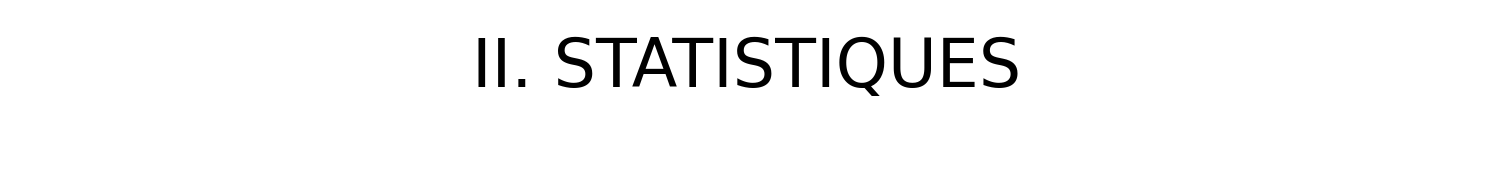

In [64]:
#CE CODE ME SERVIRA A AFFICHER LES GRANDS TITRE
commentaire = "II. STATISTIQUES"
plt.figure(figsize=(19,2))
plt.text(0.5, 0.5, commentaire, fontsize=48, ha="center")
plt.axis("off")
plt.show()

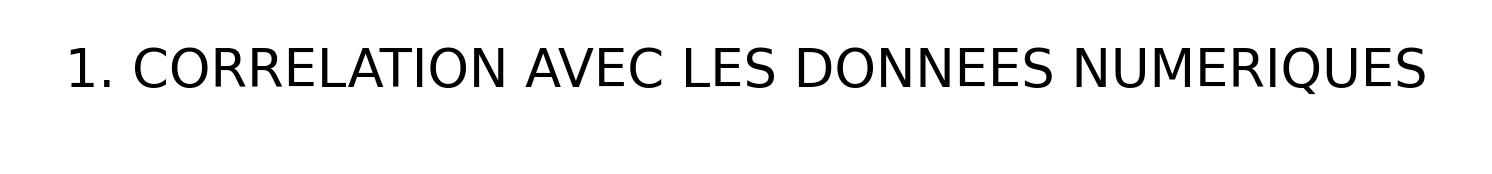

In [65]:
#CE CODE ME SERVIRA A AFFICHER LES GRANDS TITRE
commentaire = "1. CORRELATION AVEC LES DONNEES NUMERIQUES"
plt.figure(figsize=(19,2))
plt.text(0.5, 0.5, commentaire, fontsize="38", ha="center")
plt.axis("off")
plt.show()

<Axes: >

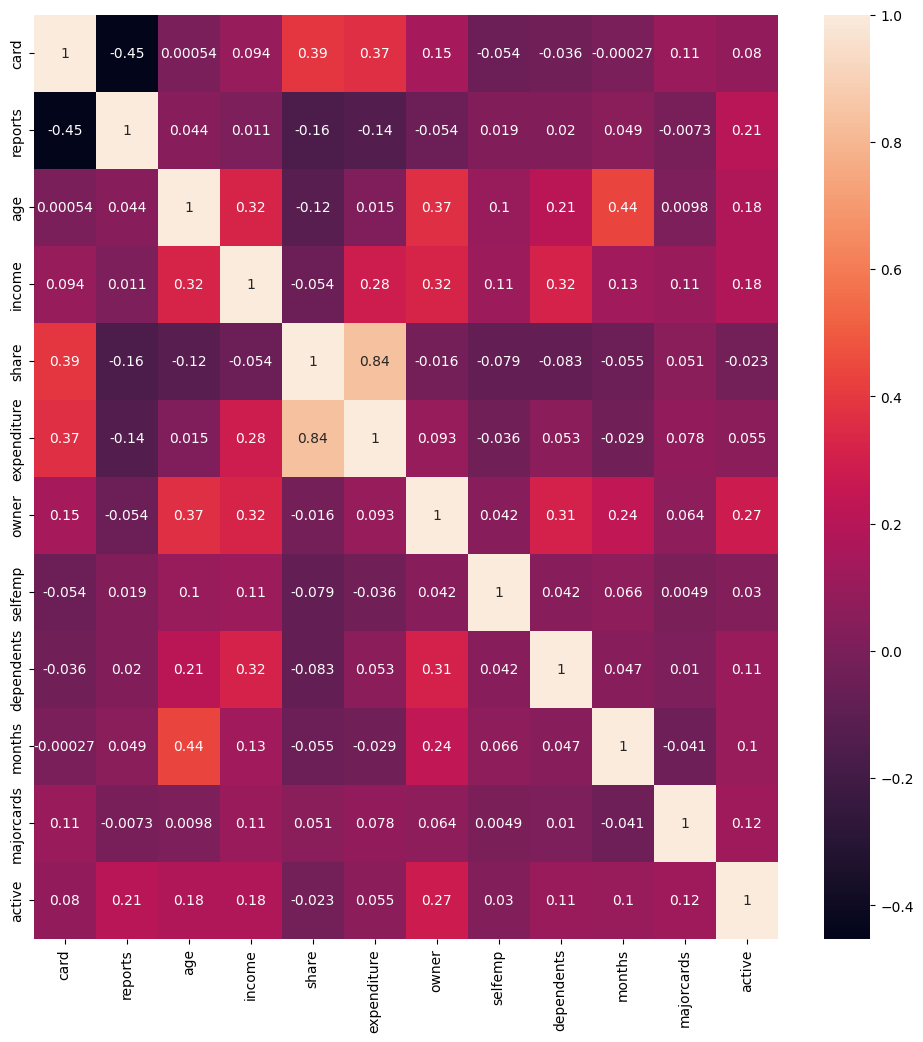

In [66]:
# matrice de corrélation
plt.figure(figsize=(12,12))
sns.heatmap(data.select_dtypes(include=['number']).corr(),annot=True)

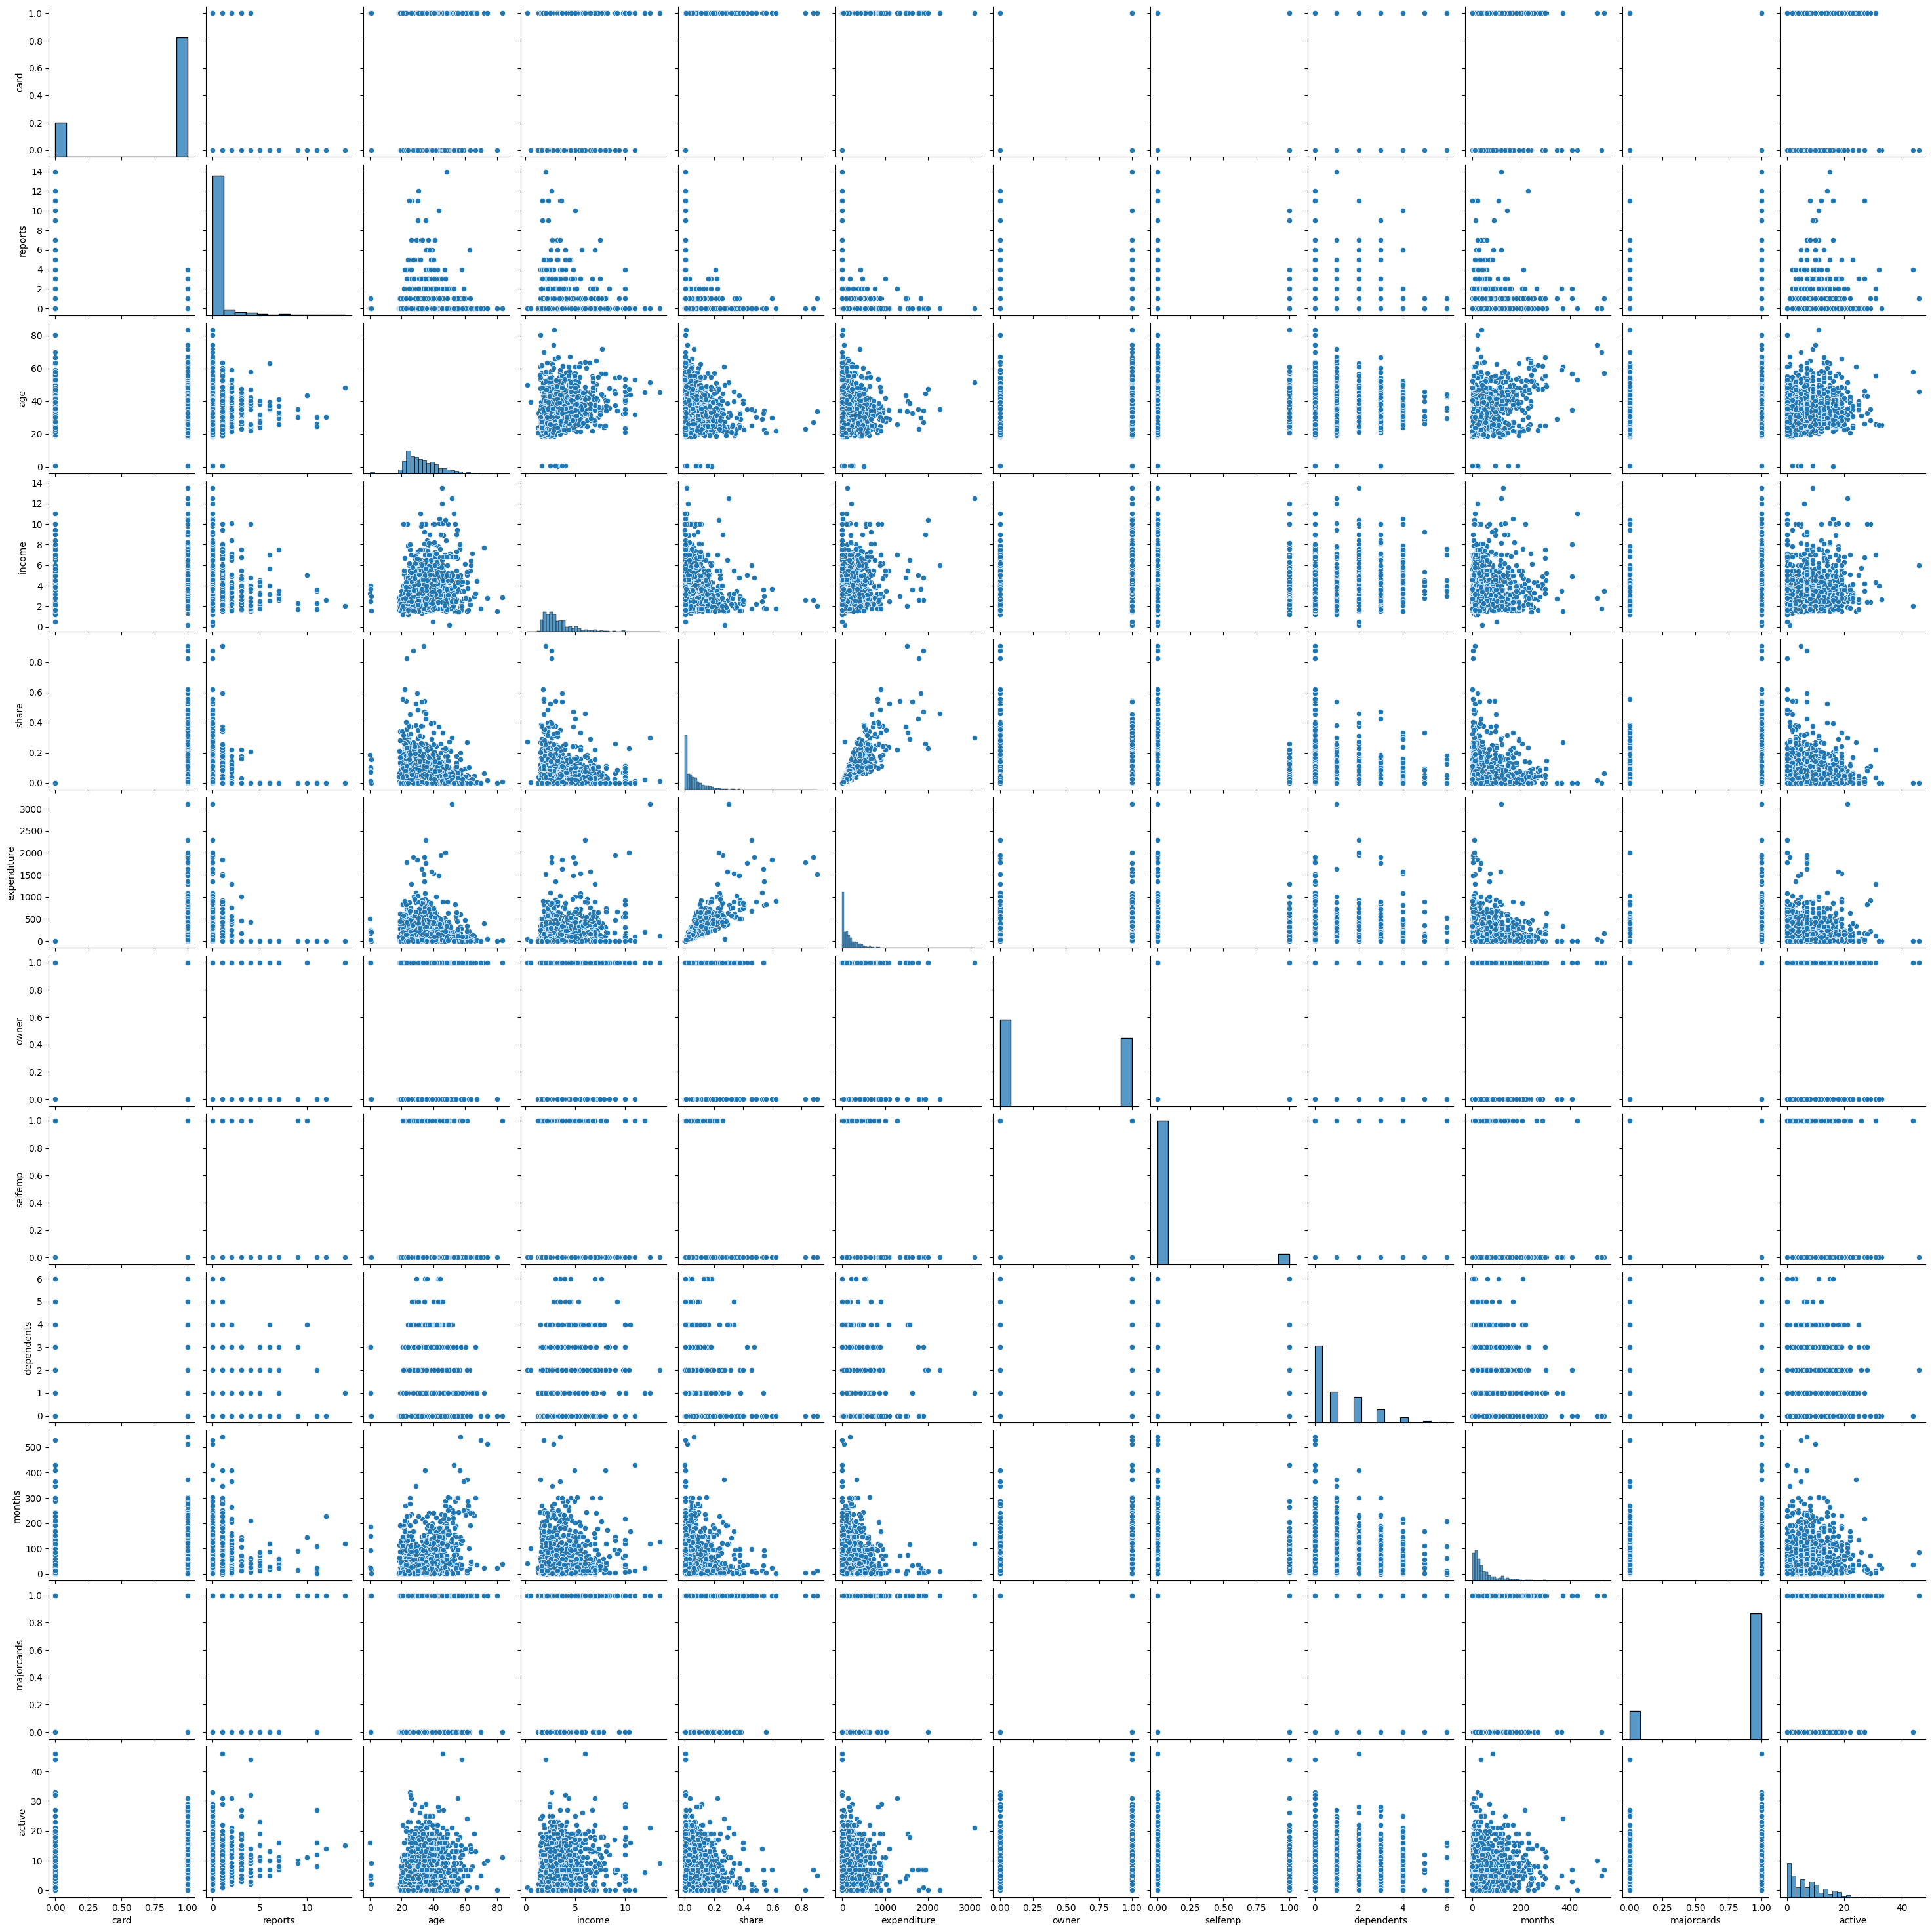

In [67]:
# Visualisation des données avec un pairplot
sns.pairplot(data.select_dtypes(include=['number']))

C:\Users\JOHANN\AppData\Local\Temp\ipykernel_17460\2328307762.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='card', y='expenditure', data=data, ci=None)


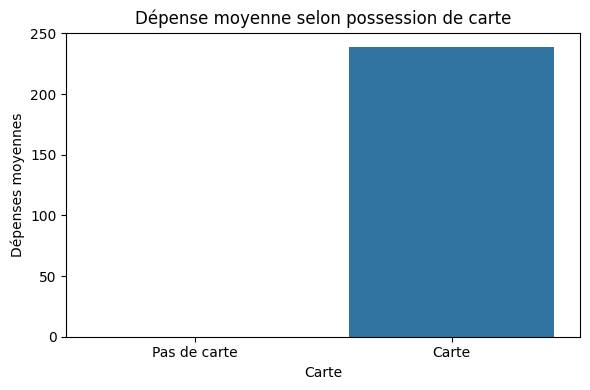

In [68]:
# -------- 1. Bar plot : Dépense moyenne selon 'card'
plt.figure(figsize=(6,4))
sns.barplot(x='card', y='expenditure', data=data, ci=None)
plt.title("Dépense moyenne selon possession de carte")
plt.xticks([0,1], ['Pas de carte', 'Carte'])
plt.ylabel("Dépenses moyennes")
plt.xlabel("Carte")
plt.tight_layout()
plt.show()

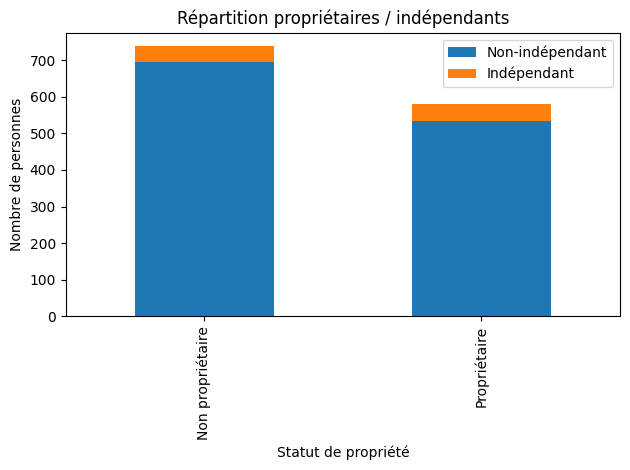

In [69]:
# -------- 2. Barres empilées : Owner vs Self-employed
owner_selfemp = pd.crosstab(data['owner'], data['selfemp'])
owner_selfemp.plot(kind='bar', stacked=True)
plt.title("Répartition propriétaires / indépendants")
plt.xticks([0,1], ['Non propriétaire', 'Propriétaire'])
plt.xlabel("Statut de propriété")
plt.ylabel("Nombre de personnes")
plt.legend(['Non-indépendant', 'Indépendant'])
plt.tight_layout()
plt.show()


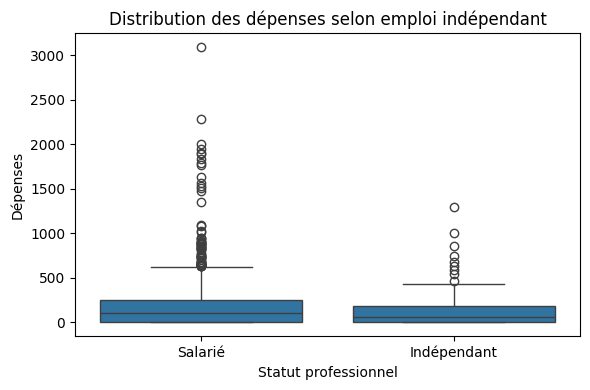

In [70]:
# -------- 3. Boxplot : Dépenses selon self-employed
plt.figure(figsize=(6,4))
sns.boxplot(x='selfemp', y='expenditure', data=data)
plt.title("Distribution des dépenses selon emploi indépendant")
plt.xticks([0,1], ['Salarié', 'Indépendant'])
plt.xlabel("Statut professionnel")
plt.ylabel("Dépenses")
plt.tight_layout()
plt.show()

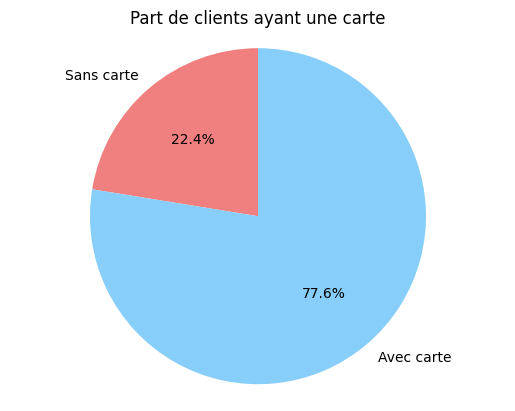

In [71]:
# -------- 4. Camembert : Pourcentage de personnes avec carte
labels = ['Sans carte', 'Avec carte']
sizes = data['card'].value_counts().sort_index()
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=['lightcoral', 'lightskyblue'])
plt.axis('equal')
plt.title("Part de clients ayant une carte")
plt.show()



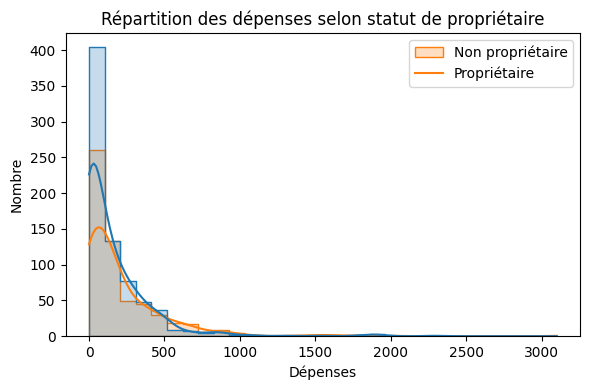

In [72]:
# -------- 5. Histogramme : Expenditure selon owner
plt.figure(figsize=(6,4))
sns.histplot(data=data, x='expenditure', hue='owner', bins=30, kde=True, element='step')
plt.title("Répartition des dépenses selon statut de propriétaire")
plt.xlabel("Dépenses")
plt.ylabel("Nombre")
plt.legend(['Non propriétaire', 'Propriétaire'])
plt.tight_layout()
plt.show()

C:\Users\JOHANN\AppData\Local\Temp\ipykernel_17460\2447445822.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x='owner', y='expenditure', palette="Pastel1")


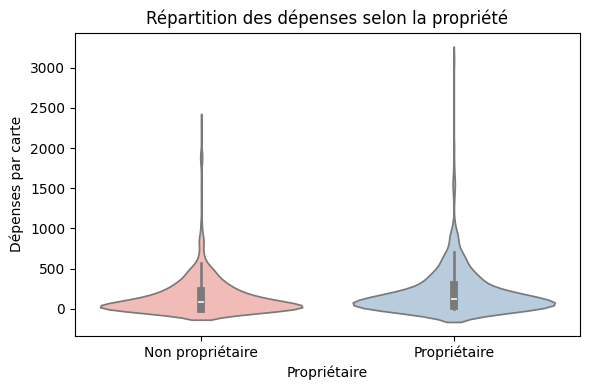

In [73]:
plt.figure(figsize=(6,4))
sns.violinplot(data=data, x='owner', y='expenditure', palette="Pastel1")
plt.title("Répartition des dépenses selon la propriété")
plt.xticks([0,1], ['Non propriétaire', 'Propriétaire'])
plt.xlabel("Propriétaire")
plt.ylabel("Dépenses par carte")
plt.tight_layout()
plt.show()


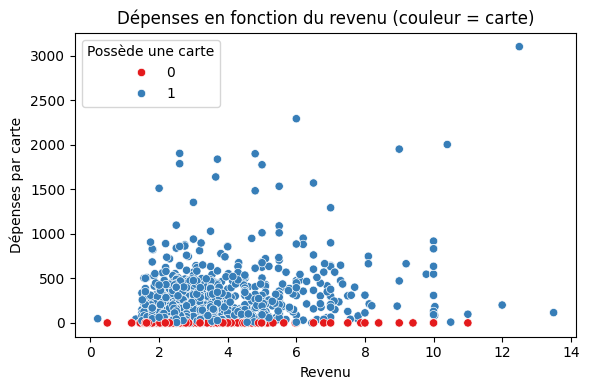

In [74]:


plt.figure(figsize=(6,4))
sns.scatterplot(data=data, x='income', y='expenditure', hue='card', palette='Set1')
plt.title("Dépenses en fonction du revenu (couleur = carte)")
plt.xlabel("Revenu")
plt.ylabel("Dépenses par carte")
plt.legend(title="Possède une carte")
plt.tight_layout()
plt.show()


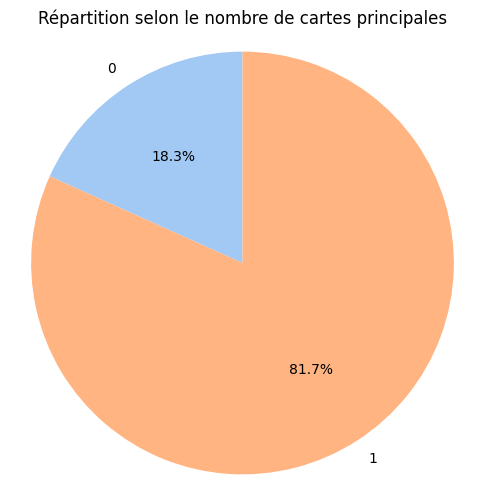

In [75]:


# Regroupement des données
majorcards_counts = data['majorcards'].value_counts().sort_index()

# Création du pie chart
plt.figure(figsize=(6,6))
plt.pie(majorcards_counts, labels=majorcards_counts.index,
        autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title("Répartition selon le nombre de cartes principales")
plt.axis('equal')
plt.show()


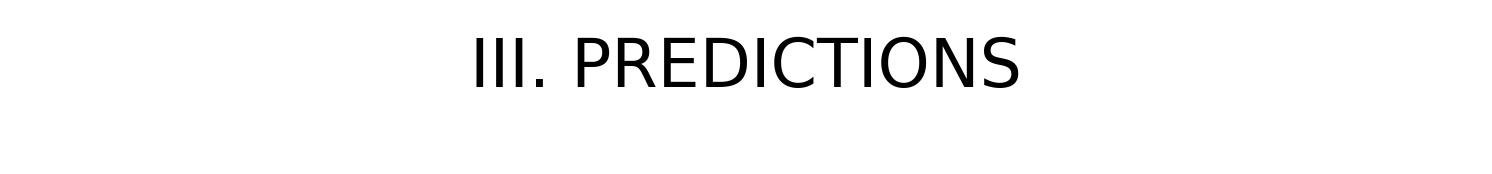

In [76]:
#CE CODE ME SERVIRA A AFFICHER LES GRANDS TITRE
commentaire = "III. PREDICTIONS"
plt.figure(figsize=(19,2))
plt.text(0.5, 0.5, commentaire, fontsize=48, ha="center")
plt.axis("off")
plt.show()

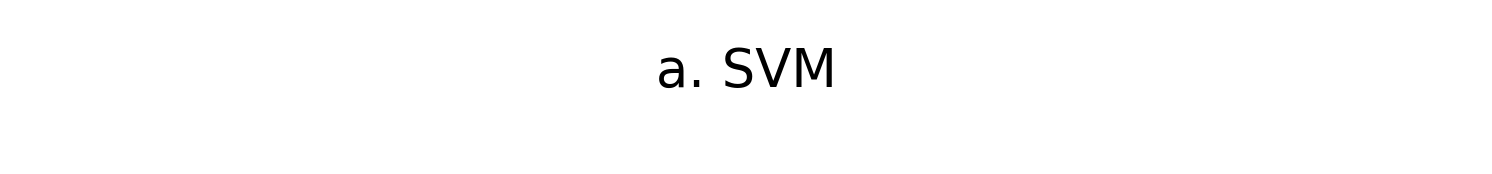

In [77]:
#CE CODE ME SERVIRA A AFFICHER LES GRANDS TITRE
commentaire = "a. SVM"
plt.figure(figsize=(19,2))
plt.text(0.5, 0.5, commentaire, fontsize="38", ha="center")
plt.axis("off")
plt.show()

In [78]:
#Je definis mon x et mon y
x=data.drop(['expenditure'],axis=1)
y=data[['expenditure']]

In [79]:
#J'importe les bibliothèque pour la prediction et l'enregistrement des modeles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import joblib

In [80]:
#80% pour l'entrainement et 20% pour le test
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [81]:
# je normalise mes données
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)
x_train

array([[ 0.55143369, -0.35058419, -1.02627753, ..., -0.73900422,
         0.47317852, -1.09002572],
       [ 0.55143369, -0.35058419, -0.54831715, ..., -0.82971212,
         0.47317852,  0.94894083],
       [ 0.55143369, -0.35058419, -0.94242517, ..., -0.73900422,
         0.47317852, -1.09002572],
       ...,
       [ 0.55143369, -0.35058419,  0.09734896, ...,  0.39484444,
         0.47317852,  0.00787935],
       [ 0.55143369, -0.35058419,  0.10573389, ...,  0.2587826 ,
         0.47317852, -0.61949498],
       [ 0.55143369, -0.35058419,  0.15604551, ...,  0.80302995,
        -2.11336728,  0.63525367]])

In [82]:
from sklearn.svm import SVR

# Création du modèle SVM pour la régression
regressor = SVR(kernel='rbf')  # tu peux aussi tester 'linear' ou 'poly'

# Entraînement du modèle
regressor.fit(x_train, y_train.values.ravel())  # .ravel() pour passer y de DataFrame à array 1D


SVR()

In [83]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Exemple avec un modèle appelé 'regressor' (ou 'xgb_model', 'best_xgb', etc.)
y_pred = regressor.predict(x_test)


# Calcul des métriques
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# Affichage
print(f"MAE (Erreur Absolue Moyenne) : {mae:.2f}")
print(f"RMSE (Racine Erreur Quadratique Moyenne) : {rmse:.2f}")
print(f"R² (coefficient de détermination) : {r2:.2f}")


MAE (Erreur Absolue Moyenne) : 148.26
RMSE (Racine Erreur Quadratique Moyenne) : 308.44
R² (coefficient de détermination) : -0.04


In [84]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


# Création d’un pipeline : normalisation + SVR
pipeline = make_pipeline(StandardScaler(), SVR(kernel='rbf'))

# Validation croisée (5 plis par défaut)
scores = cross_val_score(pipeline, x, y.values.ravel(), scoring='r2', cv=5)

# Affichage des scores
print("Scores R² pour chaque pli :", scores)
print(f"Moyenne R² : {np.mean(scores):.2f}")
print(f"Écart-type R² : {np.std(scores):.2f}")


Scores R² pour chaque pli : [ 0.07506823  0.00176395 -0.02086259 -0.03480924  0.01130239]
Moyenne R² : 0.01
Écart-type R² : 0.04


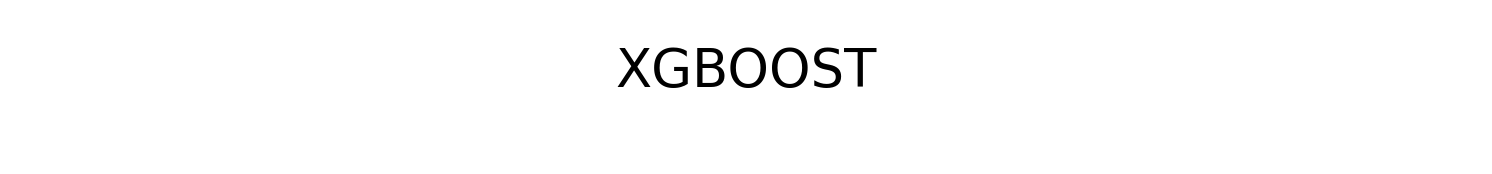

In [85]:
#CE CODE ME SERVIRA A AFFICHER LES GRANDS TITRE
commentaire = "XGBOOST"
plt.figure(figsize=(19,2))
plt.text(0.5, 0.5, commentaire, fontsize="38", ha="center")
plt.axis("off")
plt.show()

In [86]:
from xgboost import XGBRegressor

# Création du modèle XGBoost
xgb_model = XGBRegressor(objective='reg:squarederror', random_state=0)

# Entraînement
xgb_model.fit(x_train, y_train.values.ravel())


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [87]:

# Prédictions
y_pred = xgb_model.predict(x_test)

# Calcul des métriques
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# Affichage
print(f"MAE : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R² : {r2:.2f}")


MAE : 19.60
RMSE : 103.27
R² : 0.88


In [88]:

# Validation croisée sur tout le dataset
cv_scores = cross_val_score(xgb_model, x, y.values.ravel(), scoring='r2', cv=5)

# Affichage des scores
print("Scores R² par pli :", cv_scores)
print(f"Moyenne R² : {np.mean(cv_scores):.2f}")
print(f"Écart-type R² : {np.std(cv_scores):.2f}")


Scores R² par pli : [0.93994352 0.8974517  0.97267446 0.88228488 0.95015162]
Moyenne R² : 0.93
Écart-type R² : 0.03


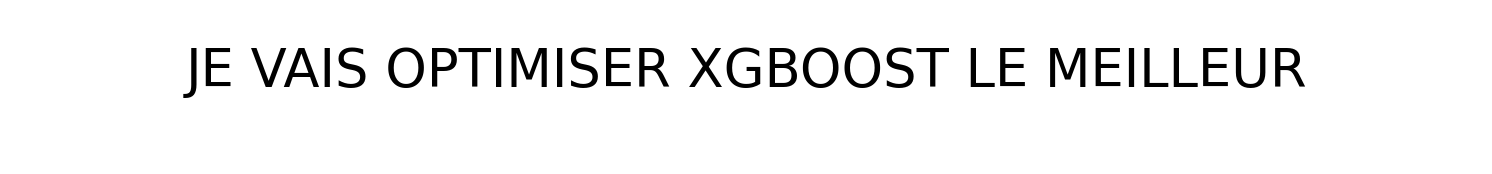

In [89]:
#CE CODE ME SERVIRA A AFFICHER LES GRANDS TITRE
commentaire = "JE VAIS OPTIMISER XGBOOST LE MEILLEUR"
plt.figure(figsize=(19,2))
plt.text(0.5, 0.5, commentaire, fontsize="38", ha="center")
plt.axis("off")
plt.show()

In [90]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV



In [91]:
# Définir la grille des hyperparamètres à tester
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.7, 1.0]
}




In [92]:
# Modèle de base
xgb = XGBRegressor(objective='reg:squarederror', random_state=0)

# Recherche des meilleurs hyperparamètres
grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid,
                           scoring='r2', cv=5, verbose=1, n_jobs=-1)

# Lancer la recherche
grid_search.fit(x, y.values.ravel())



Fitting 5 folds for each of 54 candidates, totalling 270 fits


GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None...
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.3],
                         'max_depth': [3, 4, 5], 'n_estimators': [50, 100, 200],
                         'subsample': [0.7, 1.0]},
             scoring='r2', verbose=1)

In [93]:


# Afficher les meilleurs paramètres
print("Meilleurs hyperparamètres :", grid_search.best_params_)

Meilleurs hyperparamètres : {'learning_rate': 0.3, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}


In [94]:
# Enregistrer le modèle
joblib.dump(XGBRegressor, 'JOHANN_XGBOOST.pkl')
print("Modèle enregistré sous 'JOHANN_XGBOOST.pkl'")

Modèle enregistré sous 'JOHANN_XGBOOST.pkl'
